Summary Statistics:


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-30 12:00:30.000000768,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
min,2021-10-30 00:01:00,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,2022-01-29 06:00:45,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,2022-04-30 12:00:30,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,2022-07-30 18:00:15,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,2022-10-30 00:00:00,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN
std,NaN,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN


Missing Value Report:


,Missing Count,Missing %
Comments,525600,100.0


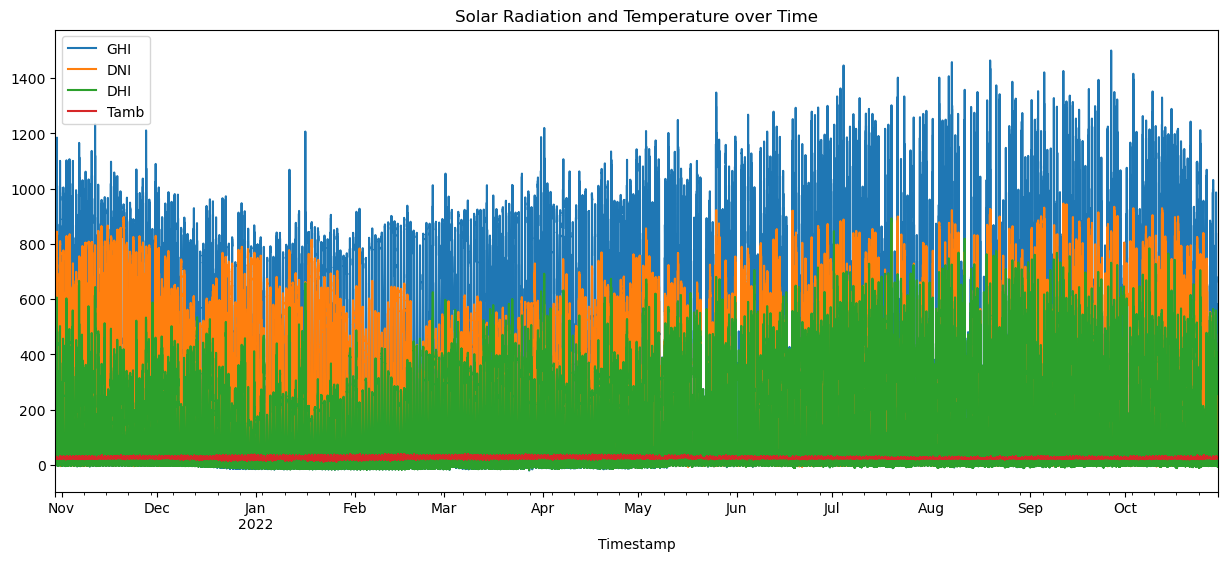

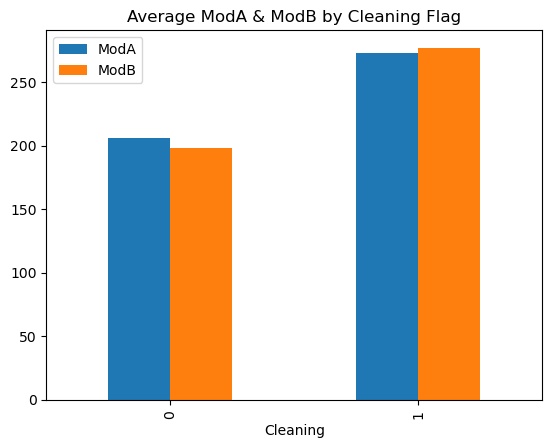

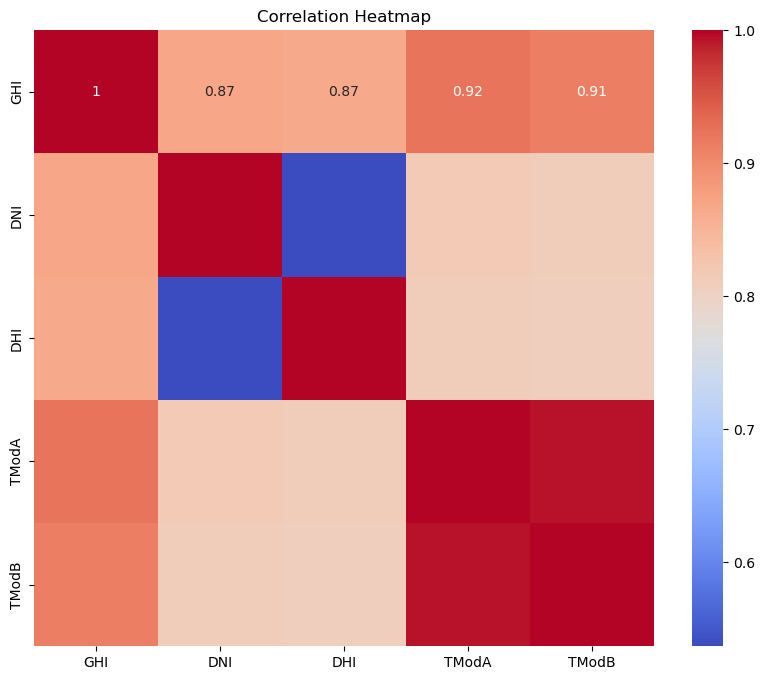

In [3]:
# benin_malanville_eda.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import os

# Load Data
df = pd.read_csv("../../data/sierraleone-bumbuna.csv", parse_dates=["Timestamp"])

# Summary Statistics
print("Summary Statistics:")
display(df.describe())

# Missing Value Report
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print("Missing Value Report:")
display(missing_report[missing_report['Missing %'] > 5])

# Outlier Detection (Z-score)
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = df[cols_to_check].apply(zscore)
df['outlier'] = (np.abs(z_scores) > 3).any(axis=1)

# Impute missing values in key columns
for col in cols_to_check:
    df[col].fillna(df[col].median(), inplace=True)

# Drop rows with missing values in essential non-sensor columns
essential_cols = ['Tamb', 'RH', 'WD', 'BP']
df_clean = df.dropna(subset=essential_cols)

# Save cleaned file
output_path = "../../data/sierraleone_clean.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_clean.to_csv(output_path, index=False)

# ---- Visualizations ----

# Time Series
df_clean.set_index("Timestamp")[['GHI', 'DNI', 'DHI', 'Tamb']].plot(figsize=(15, 6), title="Solar Radiation and Temperature over Time")
plt.show()

# Cleaning Impact
df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar', title='Average ModA & ModB by Cleaning Flag')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



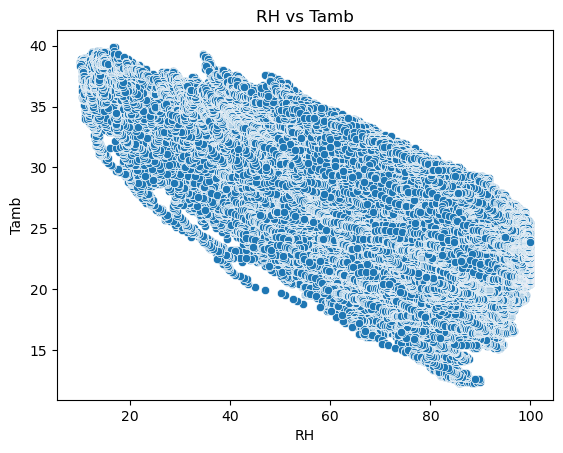

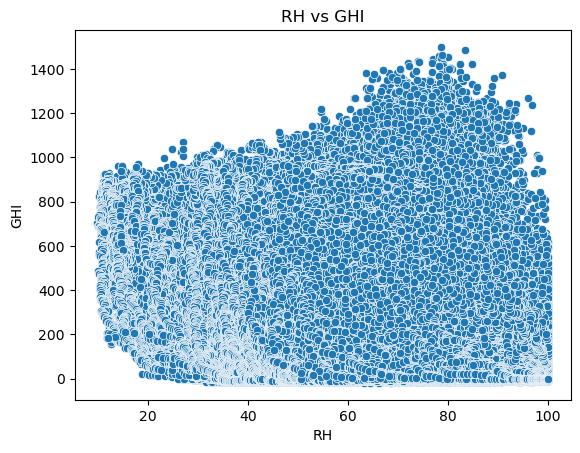

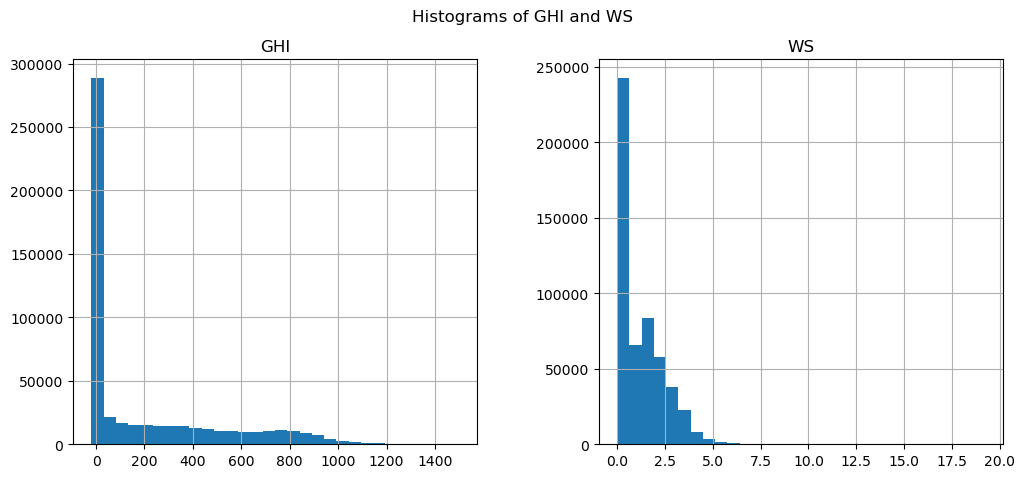

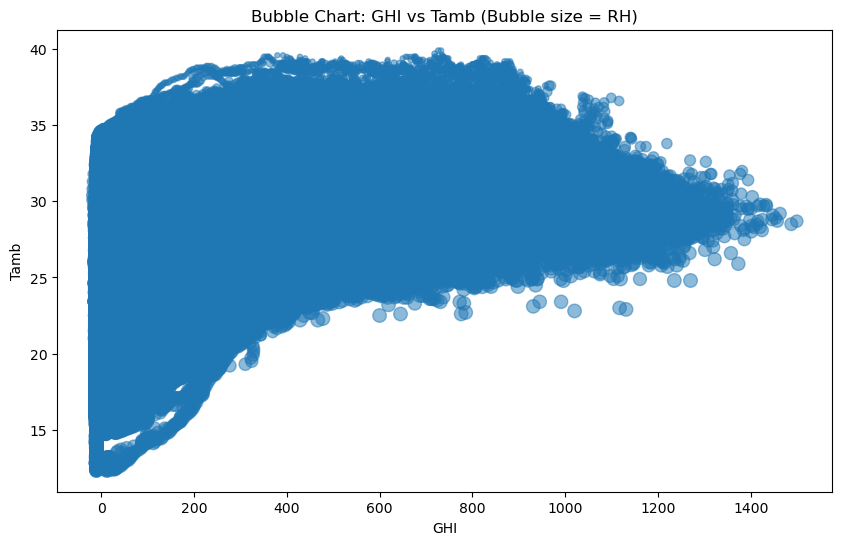

In [2]:
# Scatter Plots
#sns.pairplot(df_clean, vars=['WS', 'WSgust', 'WD'], hue='GHI')
#plt.suptitle("Wind Variables vs GHI", y=1.02)
#plt.show()

# RH vs Tamb & GHI
sns.scatterplot(data=df_clean, x='RH', y='Tamb')
plt.title("RH vs Tamb")
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='GHI')
plt.title("RH vs GHI")
plt.show()

# Histogram
df_clean[['GHI', 'WS']].hist(bins=30, figsize=(12, 5))
plt.suptitle("Histograms of GHI and WS")
plt.show()

# Bubble Chart
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['GHI'], df_clean['Tamb'], s=df_clean['RH'], alpha=0.5)
plt.xlabel("GHI")
plt.ylabel("Tamb")
plt.title("Bubble Chart: GHI vs Tamb (Bubble size = RH)")
plt.show()
